# Compare Continuous and Binned Low-Till Effects
## Fig S2(b)
This notebook reads the OLS outputs from:

- `output_linear_1999_2023/1_soy_linear_field_year`
- `output_linear_1999_2023/1_soy_bins_field_year`

and visualizes the continuous low-till-duration model together with the duration-bin model in the same plot.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

plt.style.use("seaborn-v0_8-whitegrid")

# Make the notebook work whether it is launched from the repo root or from the visualization folder.
root = Path.cwd().resolve()
if not (root / "output_linear").exists():
    root = root.parent

linear_path = root / "output_linear_1999_2023/1_soy_linear_field_year/soy_ols_field_year_terms.csv"
bins_path = root / "output_linear_1999_2023/1_soy_bins_field_year/soy_fe_duration_bins_clean_climate_terms.csv"

linear_terms = pd.read_csv(linear_path)
bin_terms = pd.read_csv(bins_path)

linear_terms.head(), bin_terms.head()


(                term  estimate  std_error    t_value       p_value  \
 0  low_till_duration  0.001659   0.000219   7.590966  9.096447e-14   
 1            GDD_4_5  0.000575   0.000035  16.309700  1.167216e-51   
 2            PPT_4_5 -0.000120   0.000014  -8.314716  4.092391e-16   
 3            GDD_6_9 -0.000003   0.000028  -0.091157  9.273912e-01   
 4            PPT_6_9  0.000078   0.000010   7.676773  4.895875e-14   
 
    pct_effect  pct_effect_low  pct_effect_high  
 0    0.166043        0.123144         0.208961  
 1    0.057488        0.050578         0.064399  
 2   -0.011976       -0.014799        -0.009153  
 3   -0.000255       -0.005742         0.005232  
 4    0.007848        0.005844         0.009851  ,
                 model                      term  estimate  std_error  \
 0  field_year_climate    till_duration_bin::1_4  0.003643   0.001396   
 1  field_year_climate    till_duration_bin::5_9  0.010971   0.001897   
 2  field_year_climate  till_duration_bin::10_14  0.

In [2]:
# Continuous model: one coefficient per additional low-till year
linear_row = linear_terms.loc[linear_terms["term"] == "low_till_duration"].iloc[0]
beta = linear_row["estimate"]
se = linear_row["std_error"]

# Build continuous prediction from 0 to 23 years.
years = np.linspace(0, 25, 300)
linear_pct = (np.exp(beta * years) - 1) * 100
linear_low = (np.exp((beta - 1.96 * se) * years) - 1) * 100
linear_high = (np.exp((beta + 1.96 * se) * years) - 1) * 100

# Duration-bin model
bin_rows = bin_terms[bin_terms["term"].str.startswith("till_duration_bin::")].copy()

bin_map = {
    "till_duration_bin::1_4": {"label": "1-4", "xmin": 1, "xmax": 4, "xmid": 2.5},
    "till_duration_bin::5_9": {"label": "5-9", "xmin": 5, "xmax": 9, "xmid": 7.0},
    "till_duration_bin::10_14": {"label": "10-14", "xmin": 10, "xmax": 14, "xmid": 12.0},
    "till_duration_bin::15_19": {"label": "15-19", "xmin": 15, "xmax": 19, "xmid": 17.0},
    "till_duration_bin::20+": {"label": "20+", "xmin": 20, "xmax": 25, "xmid": 22.5},
}

bin_rows["label"] = bin_rows["term"].map(lambda x: bin_map[x]["label"])
bin_rows["xmin"] = bin_rows["term"].map(lambda x: bin_map[x]["xmin"])
bin_rows["xmax"] = bin_rows["term"].map(lambda x: bin_map[x]["xmax"])
bin_rows["xmid"] = bin_rows["term"].map(lambda x: bin_map[x]["xmid"])

# Convert log-point effects to percent effects.
bin_rows["pct"] = (np.exp(bin_rows["estimate"]) - 1) * 100
bin_rows["pct_low"] = (np.exp(bin_rows["estimate"] - 1.96 * bin_rows["std_error"]) - 1) * 100
bin_rows["pct_high"] = (np.exp(bin_rows["estimate"] + 1.96 * bin_rows["std_error"]) - 1) * 100

bin_rows = bin_rows.sort_values("xmid").reset_index(drop=True)
bin_rows[["label", "estimate", "std_error", "pct", "pct_low", "pct_high"]].round(3)


,label,estimate,std_error,pct,pct_low,pct_high
0,1-4,0.004,0.001,0.365,0.091,0.640
1,5-9,0.011,0.002,1.103,0.728,1.480
2,10-14,0.018,0.003,1.809,1.301,2.319
3,15-19,0.026,0.003,2.629,1.933,3.329
4,20+,0.033,0.004,3.379,2.494,4.272


In [3]:
print((np.exp(beta) - 1) * 100)
print((np.exp(beta - 1.96 * se) - 1) * 100)
print((np.exp(beta + 1.96 * se) - 1) * 100)

0.16604334489584982
0.12314429341544475
0.20896077702772242


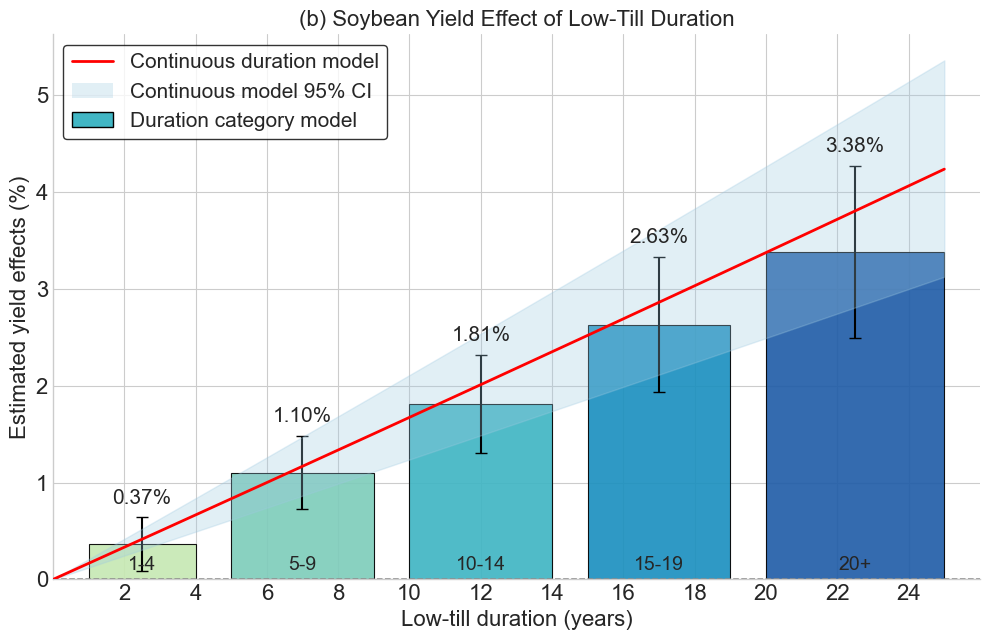

In [4]:
fig, ax = plt.subplots(figsize=(10, 6.5))

colors = ["#c7e9b4", "#7fcdbb", "#41b6c4", "#1d91c0", "#225ea8"]
bar_widths = (bin_rows["xmax"] - bin_rows["xmin"]).to_numpy()
yerr = np.vstack([
    bin_rows["pct"] - bin_rows["pct_low"],
    bin_rows["pct_high"] - bin_rows["pct"],
])

# Duration-bin estimates: same bar style as notebook 3, positioned at each bin midpoint.
bars = ax.bar(
    bin_rows["xmid"],
    bin_rows["pct"],
    width=[3,4,4,4,5],
    color=colors,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.92,
    zorder=1,
)

ax.errorbar(
    bin_rows["xmid"],
    bin_rows["pct"],
    yerr=yerr,
    fmt="none",
    ecolor="black",
    elinewidth=1.5,
    capsize=4,
    zorder=2,
)

# Continuous line + CI ribbon, drawn above the bars.
ax.fill_between(
    years,
    linear_low,
    linear_high,
    color="#9ecae1",
    alpha=0.3,
    zorder=3,
)
ax.plot(
    years,
    linear_pct,
    color="red",
    linewidth=2,
    zorder=4,
)

for bar, (_, row) in zip(bars, bin_rows.iterrows()):
    ax.text(
        row["xmid"],
        row["pct_high"] + 0.1,
        f"{row['pct']:.2f}%",
        ha="center",
        va="bottom",
        fontsize=15,
    )

ax.axhline(0, color="gray", linestyle="--", linewidth=1.1)
ax.set_title("(b) Soybean Yield Effect of Low-Till Duration", fontsize=16)
ax.set_xlabel("Low-till duration (years)", fontsize=16)
ax.set_ylabel("Estimated yield effects (%)", fontsize=16)
ax.set_xlim(0, 26)
ax.set_xticks([2, 4, 6, 8, 10, 12,  14, 16, 18, 20, 22, 24])
#ax.set_xticklabels(["0", "5", "10", "15", "20"], fontsize=16)
ax.tick_params(axis="both", labelsize=16)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for _, row in bin_rows.iterrows():
    ax.text(
        row["xmid"],
        0.01,
        row["label"],
        transform=ax.get_xaxis_transform(),
        ha="center",
        va="bottom",
        fontsize=14,
    )

legend_handles = [
    Line2D([0], [0], color="red", lw=2, label="Continuous duration model"),
    Patch(facecolor="#9ecae1", edgecolor="none", alpha=0.30, label="Continuous model 95% CI"),
    Patch(facecolor=colors[2], edgecolor="black", label="Duration category model"),
]

ax.legend(
    handles=legend_handles,
    loc="upper left",
    frameon=True,
    facecolor="white",
    edgecolor="black",
    fontsize=15,
)

plt.tight_layout()
plt.show()


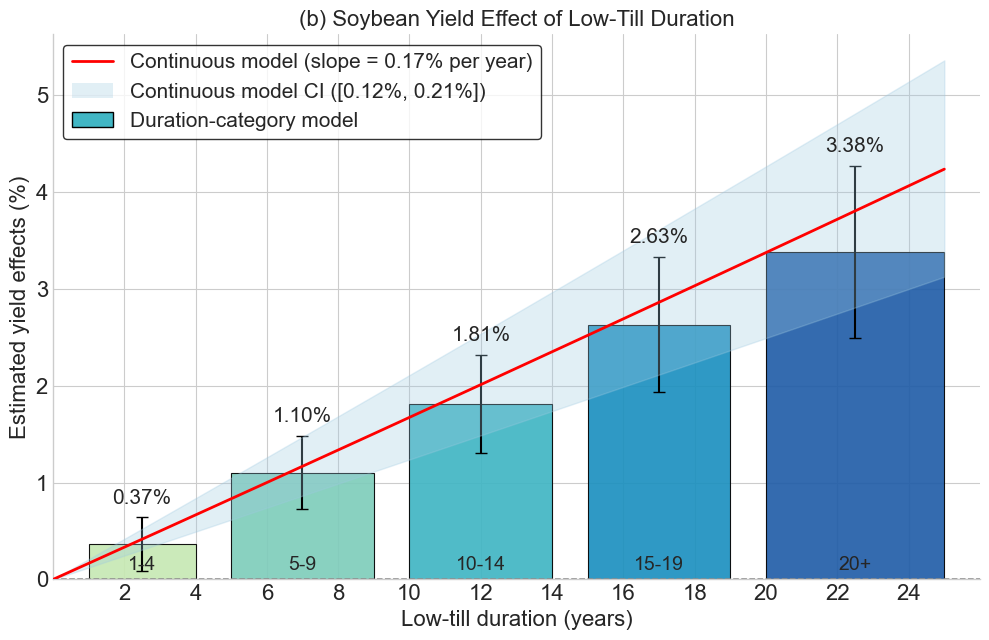

In [5]:
fig, ax = plt.subplots(figsize=(10, 6.5))

colors = ["#c7e9b4", "#7fcdbb", "#41b6c4", "#1d91c0", "#225ea8"]
bar_widths = (bin_rows["xmax"] - bin_rows["xmin"]).to_numpy()
yerr = np.vstack([
    bin_rows["pct"] - bin_rows["pct_low"],
    bin_rows["pct_high"] - bin_rows["pct"],
])

# Duration-bin estimates: same bar style as notebook 3, positioned at each bin midpoint.
bars = ax.bar(
    bin_rows["xmid"],
    bin_rows["pct"],
    width=[3, 4, 4, 4, 5],
    color=colors,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.92,
    zorder=1,
)

ax.errorbar(
    bin_rows["xmid"],
    bin_rows["pct"],
    yerr=yerr,
    fmt="none",
    ecolor="black",
    elinewidth=1.5,
    capsize=4,
    zorder=2,
)

# Continuous line + CI ribbon, drawn above the bars.
ax.fill_between(
    years,
    linear_low,
    linear_high,
    color="#9ecae1",
    alpha=0.3,
    zorder=3,
)
ax.plot(
    years,
    linear_pct,
    color="red",
    linewidth=2,
    zorder=4,
)

# Continuous model slope
slope_pct = (np.exp(beta) - 1) * 100
slope_pct_low = (np.exp(beta - 1.96 * se) - 1) * 100
slope_pct_high = (np.exp(beta + 1.96 * se) - 1) * 100

for _, row in bin_rows.iterrows():
    ax.text(
        row["xmid"],
        row["pct_high"] + 0.1,
        f"{row['pct']:.2f}%",
        ha="center",
        va="bottom",
        fontsize=15,
    )

ax.axhline(0, color="gray", linestyle="--", linewidth=1.1)
ax.set_title("(b) Soybean Yield Effect of Low-Till Duration", fontsize=16)
ax.set_xlabel("Low-till duration (years)", fontsize=16)
ax.set_ylabel("Estimated yield effects (%)", fontsize=16)
ax.set_xlim(0, 26)
ax.set_xticks([2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24])
ax.tick_params(axis="both", labelsize=16)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for _, row in bin_rows.iterrows():
    ax.text(
        row["xmid"],
        0.01,
        row["label"],
        transform=ax.get_xaxis_transform(),
        ha="center",
        va="bottom",
        fontsize=14,
    )

legend_handles = [
    Line2D(
        [0],
        [0],
        color="red",
        lw=2,
        label=f"Continuous model (slope = {slope_pct:.2f}% per year)"
    ),
    Patch(
        facecolor="#9ecae1",
        edgecolor="none",
        alpha=0.30,
        label=f"Continuous model CI ([{slope_pct_low:.2f}%, {slope_pct_high:.2f}%])",
    ),
    Patch(
        facecolor=colors[2],
        edgecolor="black",
        label="Duration-category model",
    ),
]

ax.legend(
    handles=legend_handles,
    loc="upper left",
    frameon=True,
    facecolor="white",
    edgecolor="black",
    fontsize=15,
)

plt.tight_layout()
plt.show()